In [ ]:
! wget https://raw.githubusercontent.com/chimie-paristech-CTM/PSL_notebooks/main/bayesian_optimization/base.zip
! wget https://raw.githubusercontent.com/chimie-paristech-CTM/PSL_notebooks/main/bayesian_optimization/shields_dataset.xlsx

!unzip base.zip -d base

In [25]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from baybe.parameters import NumericalDiscreteParameter, SubstanceParameter, CustomDiscreteParameter, CategoricalParameter
from baybe.objectives import SingleTargetObjective
from baybe.targets import NumericalTarget
from baybe.searchspace import SearchSpace
from baybe.surrogates import GaussianProcessSurrogate

from baybe.utils.random import set_random_seed


from baybe import Campaign
from baybe.recommenders import (
    BotorchRecommender,
    RandomRecommender,
    TwoPhaseMetaRecommender,
)
from baybe.simulation import simulate_scenarios

from base.utils import custom_fingerprinter, custom_PCA_fingerprinter, custom_PCA_from_substance
from base.pretrained_repr import PretrainedWrapper, ChemBERTa_Fingerprint, CheMeleonFingerprint, LLM_Fingerprint
from base.utils import _normalize
from base.kernels import AdaptiveKernelFactory


sseed = 142


# Load in the dataset 
The problem we study here, corresponds to the chemical reaction yield optimization from [Shields, B.J., Stevens et al. Nature 590, 89–96 (2021)](https://doi.org/10.1038/s41586-021-03213-y).
![reaction](https://raw.githubusercontent.com/emdgroup/baybe-ac24-workshop/main/files/reaction.png)

The parameters screened are:
- Solvent
- Base
- Ligand
- Concentration (of the solvent)
- Temperature

There is one target that should be maximized:
- yield

We will load in the high-throughput dataset as a lookup table, so that we do not need to run the experiments ourselves. Instead, we can look up the experimental yield for any combination of reaction parameters.


Notes 
- the structure of the molecules is represented by SMILES strings.
- optimizing the yield essentially corresponds to solving a needle-in-a-haystack problem: the data distribution is very much skewed towards low yields in the lookup dataset.


In [26]:
lookup = pd.read_excel("shields_dataset.xlsx")

# not needed, BayBE normalizes automatically
lookup["Temp_C"] = _normalize(lookup["Temp_C"]) 
lookup["Concentration"] = _normalize(lookup["Concentration"]) 

F_BEST = lookup['yield'].max()
lookup.head()


,entry,Base_SMILES,Ligand_SMILES,Solvent_SMILES,Concentration,Temp_C,yield,Base,Ligand,Solvent
0,0,O=C([O-])C.[K+],CC(C)C1=CC(C(C)C)=C(C(C(C)C)=C1)C2=C(P(C3CCCCC...,CC(N(C)C)=O,0.447917,0.5,5.47,Potassium acetate,BrettPhos,DMAc
1,1,O=C([O-])C.[K+],CC(C)(C)P(C1=CC=CC=C1)C(C)(C)C,CC(N(C)C)=O,0.447917,0.5,0.00,Potassium acetate,Di-tert-butylphenylphosphine,DMAc
2,2,O=C([O-])C.[K+],CN(C)C1=CC=CC(N(C)C)=C1C2=CC=CC=C2P(C(C)(C)C)C...,CC(N(C)C)=O,0.447917,0.5,78.95,Potassium acetate,(t-Bu)PhCPhos,DMAc
3,3,O=C([O-])C.[K+],P(C1CCCCC1)(C2CCCCC2)C3CCCCC3,CC(N(C)C)=O,0.447917,0.5,7.26,Potassium acetate,Tricyclohexylphosphine,DMAc
4,4,O=C([O-])C.[K+],P(C1=CC=CC=C1)(C2=CC=CC=C2)C3=CC=CC=C3,CC(N(C)C)=O,0.447917,0.5,28.15,Potassium acetate,PPh3,DMAc


### Setting up the search space

Just as in the introductory example, we first need to setup the search space. Instead of manually defining this here, we will extract it from the lookup dataset.

In [27]:
# extact searchspace columns

solvent_data = dict(sorted(set(zip(lookup.Solvent, lookup.Solvent_SMILES))))
base_data = dict(sorted(set(zip(lookup.Base, lookup.Base_SMILES))))
ligand_data = dict(sorted(set(zip( lookup.Ligand, lookup.Ligand_SMILES))))

temperature_values = set(lookup.Temp_C)
concentration_values = set(lookup.Concentration)

In [28]:
# Discrete numerical parameters
# Check if they are normalized properly by default
p_temp = NumericalDiscreteParameter(name = "Temp_C", values = temperature_values)
p_concentration = NumericalDiscreteParameter(name = "Concentration", values = concentration_values)

objective = SingleTargetObjective(target=NumericalTarget(name="yield", mode="MAX"))


## Substance featurizations: HSFs

Substances are featurized using hidden space features (HSF) that are reduced in dimensionality via PCA. Other decorrelation methods are available too as well as different HSFs.



In [ ]:
# get HSFs

fingerprinter = PretrainedWrapper(LLM_Fingerprint, model_name='GT4SD/multitask-text-and-chemistry-t5-base-augm', pooling_method='average', normalize_embeddings=False)
#fingerprinter = PretrainedWrapper(CheMeleonFingerprint)
#fingerprinter = PretrainedWrapper(ChemBERTa_Fingerprint, variant='zinc-base-v1')

p_solvent_t5_base = CustomDiscreteParameter(
                                        name="Solvent",
                                        data=custom_PCA_fingerprinter(solvent_data, fingerprinter, target_variance=0.98, norm="global"),
                                        decorrelate=False,)


p_base_t5_base = CustomDiscreteParameter(
                                        name="Base",
                                        data=custom_PCA_fingerprinter(base_data, fingerprinter, target_variance=0.98, norm="global"),
                                        decorrelate=False,)

p_ligand_t5_base = CustomDiscreteParameter(
                                        name="Ligand",
                                        data=custom_PCA_fingerprinter(ligand_data, fingerprinter, target_variance=0.98, norm="global"),
                                        decorrelate=False,)




Some weights of the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [30]:
p_solvent_t5_base.data.shape, p_base_t5_base.data.shape, p_ligand_t5_base.data.shape, 

((4, 3), (4, 2), (12, 6))

In [31]:
chemeleon_parameters = [
    p_solvent_t5_base,
    p_base_t5_base,
    p_ligand_t5_base,
    p_concentration,
    p_temp
]

searchspace = SearchSpace.from_product(parameters=chemeleon_parameters)


feat_dim = len(searchspace.comp_rep_columns)
feat_dim

13

## Campaign

Let's now set up a campaign; we will not specify the recommender this time, but simply adopt the default settings from BayBE (you can take a look through the scource code if you want to know the details).

In [ ]:
MC_RUNS = 10 # this will take fairly long on typical free-of-charge cloud compute
NUMBER_ITERATIONS = 26
BATCH_SIZE = 1
SWITCH_AFTER = 4

# Create adaptive surrogates
surrogate = GaussianProcessSurrogate(
    kernel_or_factory= AdaptiveKernelFactory()
)

set_random_seed(sseed)
# Use TwoPhaseMetaRecommender to handle empty training data
campaign = Campaign(
    searchspace=searchspace,
    objective=objective,
    recommender=TwoPhaseMetaRecommender(
        initial_recommender=RandomRecommender(),
        recommender=BotorchRecommender(
            surrogate_model=surrogate,
            # log more robust than simple EI
            acquisition_function="qLogExpectedImprovement"
        ),
        switch_after=SWITCH_AFTER
    )
)

In [33]:
# Run the utility for backtesting
results = simulate_scenarios(
    {'TUTORIAL': campaign},
    lookup, # the initial dataframe with the experimental results is our lookup
    batch_size = BATCH_SIZE, # how many experiments to perform in one batch
    n_doe_iterations = NUMBER_ITERATIONS, # how many batches to select successively
    n_mc_iterations = MC_RUNS, # number of Monte Carlo iterations -> this corresponds to the number of times we take a new random starting point
                                # and run the full campaign from scratch (to get a statistically) meaningful sense about the merit of the featurization approach
)
results.head()

100%|##########| 10/10 [00:21<00:00,  2.15s/it]


,Scenario,Monte_Carlo_Run,Iteration,Num_Experiments,yield_Measurements,yield_IterBest,yield_CumBest
0,TUTORIAL,0,0,1,[0.0],0.00,0.00
1,TUTORIAL,0,1,2,[0.0],0.00,0.00
2,TUTORIAL,0,2,3,[40.47],40.47,40.47
3,TUTORIAL,0,3,4,[0.0],0.00,40.47
4,TUTORIAL,0,4,5,[20.2],20.20,40.47


To visualize the campaign, we will define an auxiliary function.

In [34]:
# helpers for plotting results

PLOTARGS = {
    'linestyle': 'solid',
    'marker': 'o',
    'markersize': 6,
    'markeredgecolor': 'none'
}
FIGSIZE = (11,6)

def plot_campaign(results):
    results.rename(columns = {"Scenario": "Campaign Name"}, inplace = True)
    sns.lineplot(data = results,
             x = "Num_Experiments",
             y = "yield_CumBest",
             hue = "Campaign Name",
             **PLOTARGS)

    plt.axhline(y = F_BEST, color = 'red', linestyle = '--', label = 'Best Possible')
    plt.gcf().set_size_inches(FIGSIZE)
    plt.gca().set_ylim(plt.gca().get_ylim()[0], F_BEST+5)
    plt.title('Tutorial Campaign');

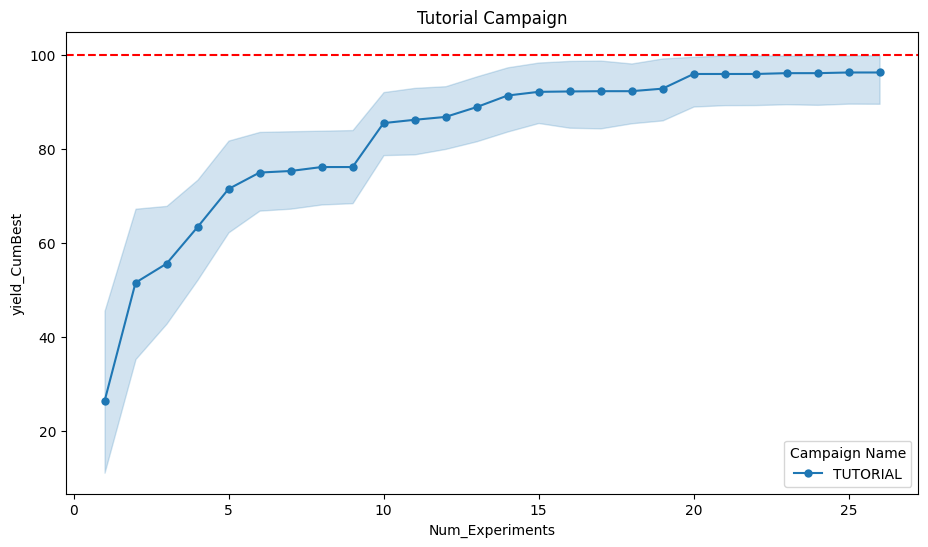

In [35]:
plot_campaign(results)